# Компоненты репутационного индекса: EDA и устойчивость рейтинга

Исследуем `index_data.csv` (все менеджеры) и `index_data_ceo.csv` (CEO).
В них уже рассчитаны пять компонент по независимым источникам. Здесь строим
итоговый индекс и сравниваем равномерные веса с CRITIC и альтернативными весами.
Образовательная компонента уже включает внутренние веса CRITIC; в этом ноутбуке
оцениваются **внешние веса пяти компонент**, а внутренние веса образования фиксированы.

Порядок анализа: доступность → распределения → связи компонент → итоговый индекс →
чувствительность весов → бутстрап CRITIC → чувствительность состава компонент.
Все таблицы сохраняются в `results/index_eda/`, графики — в PDF в `figs/`.
Исходные CSV не изменяются.

In [1]:
from pathlib import Path
import sys
import json
import hashlib
import platform
import numpy as np
import pandas as pd
import scipy
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / 'index_data.csv').exists() and (p / 'utils').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('Запустите ноутбук из проекта; сначала выполните scripts/build_index_data.py')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from utils.index_components import SCORE_COLUMNS
from utils.education_weighting import critic_weights
from utils.index_eda import bootstrap_critic, evaluate_weights, ranking_metrics, weight_scenarios

COMPONENTS = list(SCORE_COLUMNS)
LABELS = dict(zip(COMPONENTS, ['Медиа', 'Награды', 'Образование', 'Лица', 'Коммуникация']))
SAMPLE_LABELS = {'all_managers': 'Все менеджеры', 'ceo': 'CEO'}
SEED = 20260921
N_RANDOM = 1000  # для каждого из трёх распределений Dirichlet
N_BOOTSTRAP = 2000
TOP_K = 10
OUT, FIGS = ROOT / 'results/index_eda', ROOT / 'figs'
OUT.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10, 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.dpi': 110, 'pdf.fonttype': 42})
pd.set_option('display.max_columns', 20)

def save_table(frame, name, *, index=True):
    frame.to_csv(OUT / (name + '.csv'), index=index, encoding='utf-8-sig')

def finish_figure(fig, name):
    fig.tight_layout()
    fig.savefig(FIGS / ('index_eda_' + name + '.pdf'), bbox_inches='tight')
    plt.show()
    plt.close(fig)

## Шкалы, пропуски и сравнимость

Компоненты уже приведены к фиксированной шкале **0–100 до агрегации людей**.
Здесь делим на 100 для расчёта весов; повторной min–max-нормировки по выборке нет.
Все показатели трактуются как критерии выгоды: больше — выше балл.
Медиа нормировано логарифмически с искусственным максимумом 100000, награды —
логарифмически с теоретическим максимумом 20, лица — линейно с искусственными
границами [−3, 3], коммуникация — с теоретическими границами [−1, 1].
Границы образовательных признаков заданы в `utils/education_weighting.py`.

Описательная статистика каждой компоненты использует все её наблюдения.
Основной итоговый индекс рассчитывается только для компаний с **пятью доступными
компонентами**. Пропуски не заменяются нулём, веса не перераспределяются по доступным
компонентам отдельной компании. Компании без полного набора остаются в экспортируемой
таблице с пустым индексом. Это ограничивает представительность рейтинга.
Во всех экспериментах изменения весов внутри одной выборки состав компаний фиксирован.

In [2]:
INPUTS = {'all_managers': ROOT / 'index_data.csv', 'ceo': ROOT / 'index_data_ceo.csv'}
data, matrices, samples = {}, {}, []
for sample, path in INPUTS.items():
    df = pd.read_csv(path, encoding='utf-8-sig')
    assert list(df.columns) == ['ticker', *COMPONENTS]
    assert df.ticker.notna().all() and df.ticker.is_unique
    df = df.set_index('ticker').sort_index().astype(float)
    values = df.to_numpy()
    assert not np.isinf(values).any()
    assert ((values[np.isfinite(values)] >= 0) & (values[np.isfinite(values)] <= 100)).all()
    data[sample] = df
    matrices[sample] = df.dropna() / 100
    if len(matrices[sample]) < 3:
        raise ValueError(f'{sample}: недостаточно полных наблюдений')
    samples.append({'sample': sample, 'companies_total': len(df),
                    'complete_companies': len(matrices[sample]),
                    'excluded_companies': int(df.isna().any(axis=1).sum()),
                    'bootstrap_rows_per_draw': len(matrices[sample])})
    eligibility = pd.DataFrame({'included': df.notna().all(axis=1),
        'available_components': df.notna().sum(axis=1),
        'missing_components': df.isna().apply(lambda row: ', '.join(row.index[row]), axis=1)})
    save_table(eligibility, f'{sample}_eligibility')
sample_audit = pd.DataFrame(samples).set_index('sample')
display(sample_audit)
save_table(sample_audit, 'sample_audit')

,companies_total,complete_companies,excluded_companies,bootstrap_rows_per_draw
sample,,,,
all_managers,110,64,46,64
ceo,110,28,82,28


## Доступность и описательная статистика компонент

Нулевой балл — наблюдаемое значение и не считается пропуском. Дополнительно сравниваем
средние доступных показателей у компаний, вошедших и не вошедших в полный рейтинг.
Такое сравнение описывает отбор, но не доказывает случайность или неслучайность пропусков.

### Все менеджеры

,count,mean,std,min,5%,25%,50%,75%,95%,max,missing,missing_pct,zero_count,hundred_count,skewness,excess_kurtosis
component,,,,,,,,,,,,,,,,
media_score,109.0,56.711,7.200,33.717,43.600,53.915,57.598,61.535,66.162,73.451,1,0.909,0,0,-0.583,0.627
awards_score,109.0,8.056,11.823,0.000,0.000,0.000,4.527,11.384,32.218,72.170,1,0.909,37,0,2.755,9.691
expertise_score,110.0,39.187,11.992,12.453,20.621,29.905,40.090,47.232,56.635,72.542,0,0.000,0,0,0.195,-0.173
face_score,79.0,49.585,6.495,33.322,38.077,45.062,50.379,53.483,58.263,66.743,31,28.182,0,0,-0.212,0.473
communication_score,83.0,94.578,20.678,0.000,50.000,100.000,100.000,100.000,100.000,100.000,27,24.545,3,77,-3.946,14.971


### CEO

,count,mean,std,min,5%,25%,50%,75%,95%,max,missing,missing_pct,zero_count,hundred_count,skewness,excess_kurtosis
component,,,,,,,,,,,,,,,,
media_score,78.0,61.402,8.311,39.370,50.130,56.228,60.788,65.987,73.679,85.616,32,29.091,0,0,0.459,0.807
awards_score,91.0,11.407,21.263,0.000,0.000,0.000,0.000,20.405,63.576,75.630,19,17.273,66,0,1.763,1.958
expertise_score,105.0,40.228,16.374,7.571,11.798,26.910,42.770,51.823,62.736,80.708,5,4.545,0,0,-0.317,-0.713
face_score,43.0,51.315,8.209,29.960,35.930,45.369,52.660,57.425,61.629,64.523,67,60.909,0,0,-0.673,-0.118
communication_score,83.0,94.578,20.678,0.000,50.000,100.000,100.000,100.000,100.000,100.000,27,24.545,3,77,-3.946,14.971


,sample,component,included_n,excluded_observed_n,included_mean,excluded_mean,mean_difference
0,all_managers,media_score,64,45,56.87,56.48,0.40
1,all_managers,awards_score,64,45,8.60,7.29,1.31
2,all_managers,expertise_score,64,46,39.02,39.43,-0.41
3,all_managers,face_score,64,15,49.91,48.22,1.68
4,all_managers,communication_score,64,19,96.09,89.47,6.62
5,ceo,media_score,28,50,61.86,61.15,0.71
6,ceo,awards_score,28,63,7.50,13.14,-5.64
7,ceo,expertise_score,28,77,43.55,39.02,4.54
8,ceo,face_score,28,15,53.37,47.47,5.90
9,ceo,communication_score,28,55,100.00,91.82,8.18


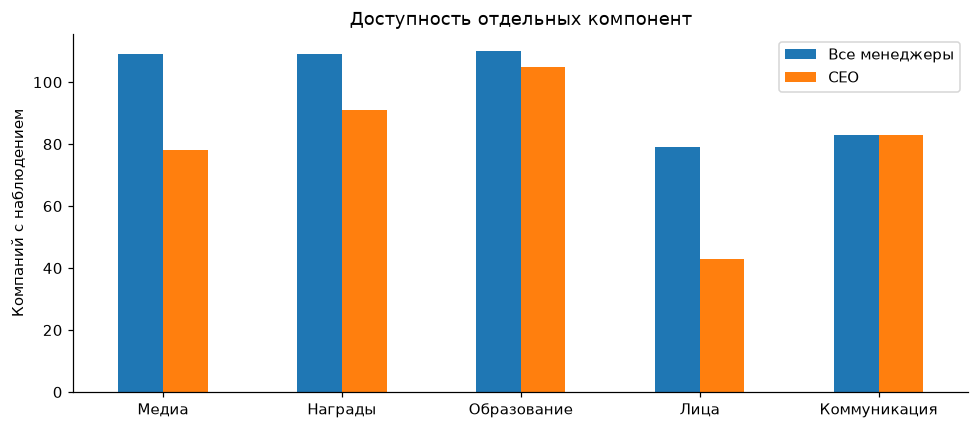

In [3]:
descriptives, coverage, selection = {}, {}, []
for sample, df in data.items():
    stats = df.describe(percentiles=[.05, .25, .5, .75, .95]).T
    stats['missing'] = df.isna().sum()
    stats['missing_pct'] = 100 * df.isna().mean()
    stats['zero_count'] = df.eq(0).sum()
    stats['hundred_count'] = df.eq(100).sum()
    stats['skewness'] = df.skew()
    stats['excess_kurtosis'] = df.kurt()
    stats.index.name = 'component'
    descriptives[sample] = stats
    coverage[sample] = df.notna().sum()
    display(Markdown('### ' + SAMPLE_LABELS[sample]))
    display(stats.round(3))
    save_table(stats, f'{sample}_component_descriptive')
    missing_patterns = df.isna().apply(lambda row: ', '.join(row.index[row]) or 'complete', axis=1)
    save_table(missing_patterns.value_counts().rename_axis('missing_components').to_frame('companies'),
               f'{sample}_missing_patterns')
    eligible = df.notna().all(axis=1)
    for col in COMPONENTS:
        inside, outside = df.loc[eligible, col].dropna(), df.loc[~eligible, col].dropna()
        selection.append({'sample': sample, 'component': col,
                          'included_n': len(inside), 'excluded_observed_n': len(outside),
                          'included_mean': inside.mean(), 'excluded_mean': outside.mean(),
                          'mean_difference': inside.mean() - outside.mean()})
coverage_table = pd.DataFrame(coverage)
selection_table = pd.DataFrame(selection)
save_table(coverage_table, 'component_coverage')
save_table(selection_table, 'complete_case_selection', index=False)
display(selection_table.round(2))
fig, ax = plt.subplots(figsize=(9, 4))
coverage_table.rename(index=LABELS, columns=SAMPLE_LABELS).plot.bar(ax=ax, rot=0)
ax.set(ylabel='Компаний с наблюдением', xlabel='', title='Доступность отдельных компонент')
finish_figure(fig, 'coverage')

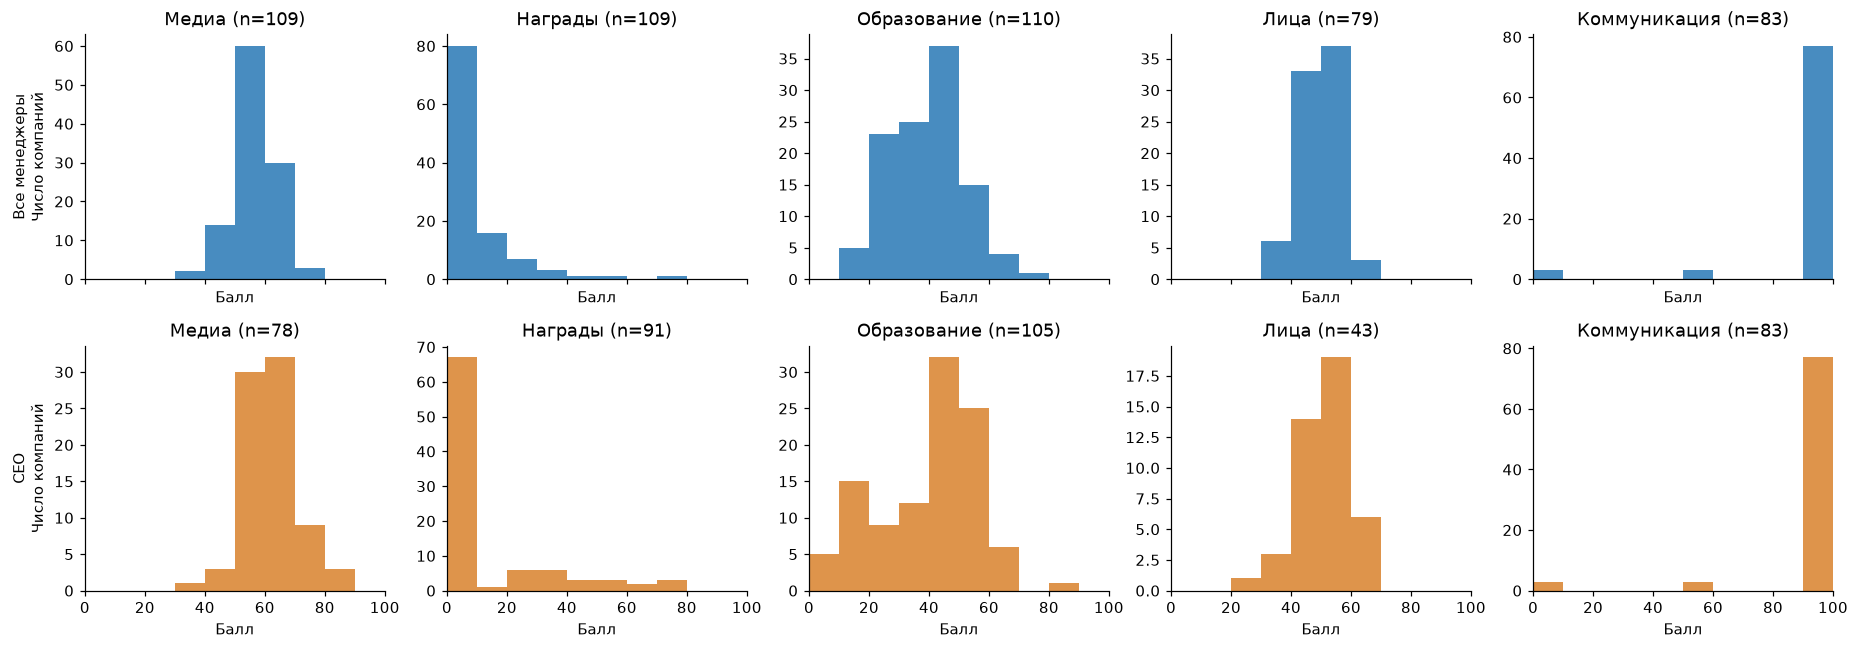

In [4]:
fig, axes = plt.subplots(2, len(COMPONENTS), figsize=(17, 6), sharex=True)
for row, (sample, df) in enumerate(data.items()):
    for j, col in enumerate(COMPONENTS):
        axes[row, j].hist(df[col].dropna(), bins=np.linspace(0, 100, 11), color=['#2878B5', '#D9822B'][row], alpha=.85)
        axes[row, j].set(title=f'{LABELS[col]} (n={df[col].count()})', xlim=(0, 100), xlabel='Балл')
        if j == 0:
            axes[row, j].set_ylabel(SAMPLE_LABELS[sample] + '\nЧисло компаний')
finish_figure(fig, 'component_distributions')

## Связи между компонентами

Таблицы Pearson и Spearman рассчитаны по попарно доступным наблюдениям вместе
с матрицей числа компаний для каждой пары. Для рейтинга и CRITIC используется
отдельная корреляционная матрица на полном фиксированном составе компаний.
Смешивать эти два способа отбора при оценке весов нельзя.

Попарные числа наблюдений: **Все менеджеры**

,media_score,awards_score,expertise_score,face_score,communication_score
media_score,109,109,109,79,83
awards_score,109,109,109,79,83
expertise_score,109,109,110,79,83
face_score,79,79,79,79,64
communication_score,83,83,83,64,83


Попарные числа наблюдений: **CEO**

,media_score,awards_score,expertise_score,face_score,communication_score
media_score,78,78,74,37,60
awards_score,78,91,87,43,70
expertise_score,74,87,105,41,82
face_score,37,43,41,43,35
communication_score,60,70,82,35,83


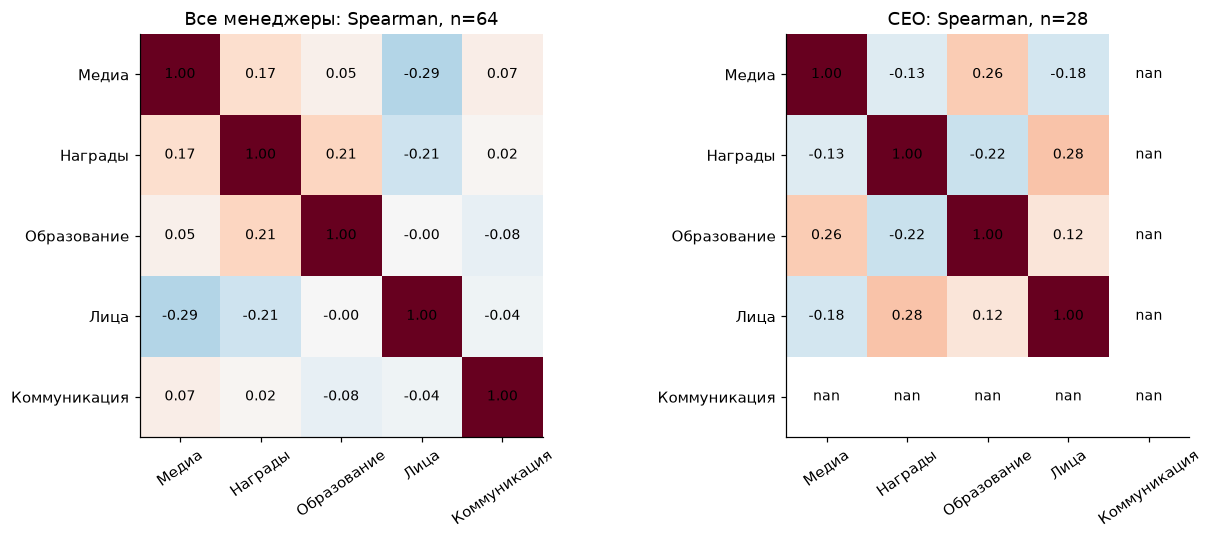

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (sample, df) in zip(axes, data.items()):
    observed = df.notna().astype(int)
    pair_counts = observed.T @ observed
    save_table(pair_counts, f'{sample}_pairwise_counts')
    for method in ['pearson', 'spearman']:
        save_table(df.corr(method=method, min_periods=3), f'{sample}_pairwise_{method}')
        save_table(matrices[sample].corr(method=method), f'{sample}_complete_{method}')
    corr = matrices[sample].corr(method='spearman')
    ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
    for i in range(len(COMPONENTS)):
        for j in range(len(COMPONENTS)):
            ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
    ax.set(xticks=range(5), yticks=range(5), xticklabels=list(LABELS.values()),
           yticklabels=list(LABELS.values()), title=f'{SAMPLE_LABELS[sample]}: Spearman, n={len(matrices[sample])}')
    ax.tick_params(axis='x', rotation=35)
    display(Markdown('Попарные числа наблюдений: **' + SAMPLE_LABELS[sample] + '**'))
    display(pair_counts)
finish_figure(fig, 'component_correlations')

## Равномерные веса и CRITIC

Базовый индекс: $I_i=100\sum_j w_j z_{ij}$, где $z_{ij}=x_{ij}/100$ и $w_j=1/5$.
CRITIC использует стандартное отклонение и конфликт критериев:
$C_j=\sigma_j\sum_k(1-r_{jk})$, $w_j=C_j/\sum_k C_k$.
$r$ — корреляция Пирсона со знаком. Постоянная компонента получает нулевой вес
CRITIC; в равномерной модели все пять весов остаются равны 0.2.
Если конфликт полностью отсутствует, CRITIC не определён и выдаёт ошибку.

Источник: [Diakoulaki, Mavrotas & Papayannakis (1995), DOI](https://doi.org/10.1016/0305-0548(94)00059-H),
[полный текст](https://reformship.github.io/pages/1capacity/1model/11evaluation/Determining%20objective%20weights%20in%20multiple%20criteria%20problems%20The%20CRITIC%20method.pdf).
В отличие от выборочной нормировки в статье, здесь сохраняются фиксированные шкалы
проекта. CRITIC отражает структуру вариации данных, а не доказанную важность компонент
для репутации. Веса рассчитываются отдельно для двух выборок.

### Все менеджеры

,equal,critic
component,,
media_score,0.2,0.1294
awards_score,0.2,0.2240
expertise_score,0.2,0.2053
face_score,0.2,0.1421
communication_score,0.2,0.2992


,count,mean,std,min,25%,50%,75%,max
equal,64.0,50.097,5.443,25.005,47.31,50.458,53.018,68.098
critic,64.0,53.136,6.587,19.086,50.63,53.209,56.594,73.105


,index_equal,index_critic,rank_equal,rank_critic,rank_change_critic_minus_equal,absolute_rank_change
ticker,,,,,,
APTK,68.098,73.105,1.0,1.0,0.0,0.0
RENI,58.915,63.222,3.0,2.0,-1.0,1.0
FIVE,59.403,63.039,2.0,3.0,1.0,1.0
GMKN,56.237,60.865,6.0,4.0,-2.0,2.0
MTSS,57.811,60.771,4.0,5.0,1.0,1.0
AGRO,57.062,59.387,5.0,6.0,1.0,1.0
SGZH,54.347,58.333,8.0,7.0,-1.0,1.0
ASTR,54.261,58.228,9.0,8.0,-1.0,1.0
CIAN,54.486,57.770,7.0,9.0,2.0,2.0


### CEO

,equal,critic
component,,
media_score,0.2,0.1571
awards_score,0.2,0.4090
expertise_score,0.2,0.2828
face_score,0.2,0.1511
communication_score,0.2,0.0000


,count,mean,std,min,25%,50%,75%,max
equal,28.0,53.258,4.986,43.092,50.407,53.068,56.569,64.177
critic,28.0,33.170,8.197,18.881,28.752,31.728,36.086,53.971


,index_equal,index_critic,rank_equal,rank_critic,rank_change_critic_minus_equal,absolute_rank_change
ticker,,,,,,
HEAD,63.567,53.971,2.0,1.0,-1.0,1.0
FIVE,64.177,53.350,1.0,2.0,1.0,1.0
RENI,58.297,46.961,4.0,3.0,-1.0,1.0
DATA,58.733,42.281,3.0,4.0,1.0,1.0
DELI,54.419,36.788,12.0,5.0,-7.0,7.0
ETLN,56.687,36.477,7.0,6.0,-1.0,1.0
NKNC,58.292,36.266,5.0,7.0,2.0,2.0
MRKV,57.159,36.026,6.0,8.0,2.0,2.0
AGRO,56.530,35.708,8.0,9.0,1.0,1.0


,spearman,kendall_tau_b,mean_abs_rank_shift,max_abs_rank_shift,top_k_jaccard
sample,,,,,
all_managers,0.9894,0.9276,1.9062,8.0,1.0000
ceo,0.9633,0.8571,1.5000,7.0,0.6667


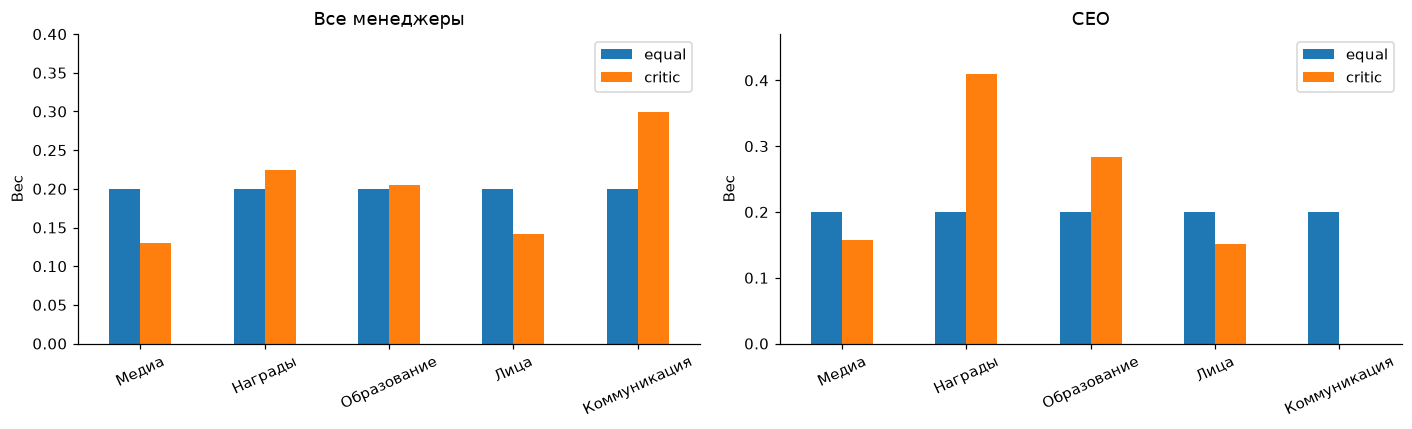

In [6]:
point_weights, index_tables, critic_details, point_metrics = {}, {}, {}, []
for sample, x in matrices.items():
    w, details = critic_weights(x)
    weights = pd.DataFrame({'equal': 1 / len(COMPONENTS), 'critic': w})
    weights.index.name = 'component'
    point_weights[sample], critic_details[sample] = weights, details
    scores = 100 * x.dot(weights)
    table = scores.add_prefix('index_').join(scores.rank(ascending=False, method='average').add_prefix('rank_'))
    table['rank_change_critic_minus_equal'] = table.rank_critic - table.rank_equal
    table['absolute_rank_change'] = table.rank_change_critic_minus_equal.abs()
    index_tables[sample] = table
    point_metrics.append({'sample': sample, **ranking_metrics(scores.equal, scores.critic, top_k=TOP_K)})
    save_table(weights, f'{sample}_point_weights')
    save_table(details, f'{sample}_critic_details')
    save_table(data[sample].join(table), f'{sample}_indices')
    save_table(scores.describe(percentiles=[.05, .25, .5, .75, .95]).T, f'{sample}_index_descriptive')
    display(Markdown('### ' + SAMPLE_LABELS[sample]))
    display(weights.round(4))
    display(scores.describe().T.round(3))
    display(table.sort_values('rank_critic').head(TOP_K).round(3))
point_metrics = pd.DataFrame(point_metrics).set_index('sample')
display(point_metrics.round(4))
save_table(point_metrics, 'critic_vs_equal')
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (sample, weights) in zip(axes, point_weights.items()):
    weights.rename(index=LABELS).plot.bar(ax=ax, rot=25)
    ax.set(title=SAMPLE_LABELS[sample], ylabel='Вес', xlabel='', ylim=(0, max(.4, weights.max().max() * 1.15)))
finish_figure(fig, 'point_weights')

Наибольшие сдвиги ранга: **Все менеджеры**

,index_equal,index_critic,rank_equal,rank_critic,rank_change_critic_minus_equal,absolute_rank_change
ticker,,,,,,
MRKU,45.140,50.335,58.0,50.0,-8.0,8.0
RUAL,47.149,51.761,49.0,42.0,-7.0,7.0
GAZP,53.853,56.576,11.0,17.0,6.0,6.0
SBER,45.961,43.166,55.0,61.0,6.0,6.0
FEES,51.261,55.065,26.0,21.0,-5.0,5.0
MRKV,48.155,52.371,43.0,38.0,-5.0,5.0
OZPH,48.603,51.352,40.0,45.0,5.0,5.0
FIXP,50.613,53.007,32.0,36.0,4.0,4.0
LSNGP,49.998,53.428,35.0,31.0,-4.0,4.0


Наибольшие сдвиги ранга: **CEO**

,index_equal,index_critic,rank_equal,rank_critic,rank_change_critic_minus_equal,absolute_rank_change
ticker,,,,,,
DELI,54.419,36.788,12.0,5.0,-7.0,7.0
TATN,50.518,26.646,20.0,25.0,5.0,5.0
GAZP,55.168,33.104,9.0,12.0,3.0,3.0
HYDR,49.170,28.747,25.0,22.0,-3.0,3.0
IRAO,51.805,29.959,16.0,19.0,3.0,3.0
KAZT,51.508,31.613,18.0,15.0,-3.0,3.0
EUTR,51.232,30.267,19.0,17.0,-2.0,2.0
MRKV,57.159,36.026,6.0,8.0,2.0,2.0
NKNC,58.292,36.266,5.0,7.0,2.0,2.0


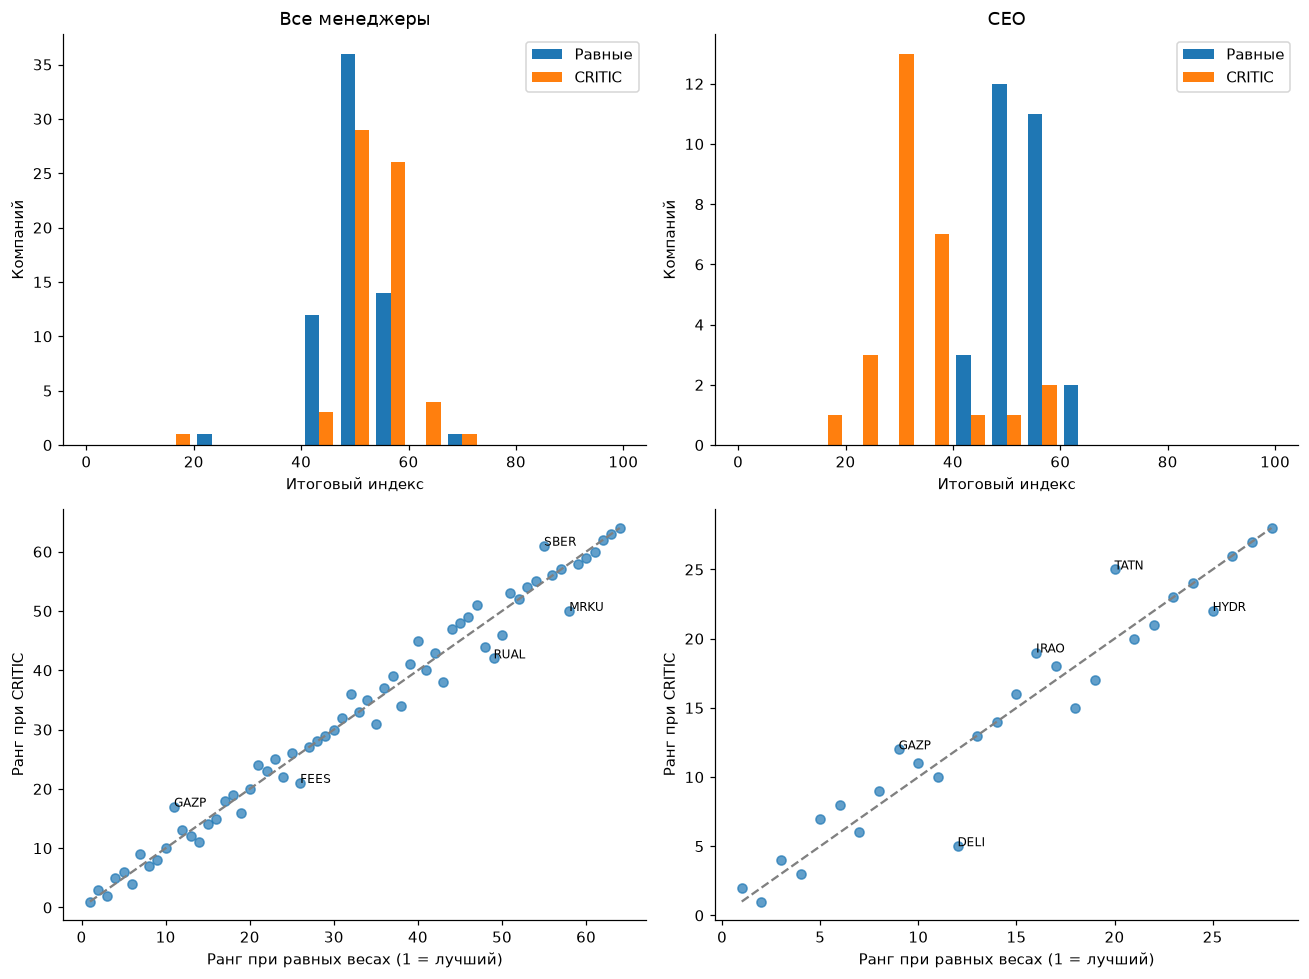

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for col, (sample, table) in enumerate(index_tables.items()):
    ax = axes[0, col]
    ax.hist([table.index_equal, table.index_critic], bins=np.linspace(0, 100, 16), label=['Равные', 'CRITIC'])
    ax.set(title=SAMPLE_LABELS[sample], xlabel='Итоговый индекс', ylabel='Компаний')
    ax.legend()
    ax = axes[1, col]
    ax.scatter(table.rank_equal, table.rank_critic, alpha=.7)
    ax.plot([1, len(table)], [1, len(table)], '--', color='gray')
    for ticker, row in table.nlargest(5, 'absolute_rank_change').iterrows():
        ax.annotate(ticker, (row.rank_equal, row.rank_critic), fontsize=8)
    ax.set(xlabel='Ранг при равных весах (1 = лучший)', ylabel='Ранг при CRITIC')
    display(Markdown('Наибольшие сдвиги ранга: **' + SAMPLE_LABELS[sample] + '**'))
    display(table.nlargest(10, 'absolute_rank_change').round(3))
finish_figure(fig, 'index_distribution_and_ranks')

## Робастность к выбору внешних весов

Меняем только веса, сохраняя нормировку, баллы и список компаний.
Три симметричных распределения Dirichlet имеют одинаковое математическое ожидание
$(0.2,\ldots,0.2)$: $\alpha=10$ даёт умеренные отклонения, $\alpha=1$ равномерно
покрывает симплекс, $\alpha=0.2$ чаще даёт концентрированные веса. По 1000 реализаций
каждого типа (параметр `N_RANDOM`). Это сценарный анализ, не вероятностная модель
«истинных» весов и не доказательство устойчивости ко всем возможным весам.

Дополнительно вес каждой компоненты меняется от 0 до 1 с шагом 0.05;
остаток делится поровну между четырьмя остальными. Ноль — исключение компоненты,
единица — рейтинг только по ней. Одинаковые наборы весов применяются к обеим выборкам.

Метрики относительно равных весов: Spearman, Kendall τ-b (с учётом ничьих), средний
и максимальный абсолютный сдвиг ранга, Jaccard состава топ-10. Ранг 1 — лучший,
при равенстве баллов используются средние ранги. В топ включаются все компании,
разделяющие граничное место, поэтому он иногда содержит больше 10 компаний.
Неопределённая корреляция постоянного рейтинга сохраняется пустой и учитывается
в числе таких сценариев. Значения Spearman ниже 0.9 и 0.8 — описательные пороги,
а не статистические тесты.

In [8]:
scenario_weights, scenario_labels = weight_scenarios(COMPONENTS, draws=N_RANDOM, seed=SEED)
save_table(scenario_weights.join(scenario_labels), 'weight_scenarios')
sensitivity, sensitivity_summaries = {}, []
for sample, x in matrices.items():
    metrics = evaluate_weights(x, scenario_weights, top_k=TOP_K).join(scenario_labels)
    sensitivity[sample] = metrics
    save_table(metrics, f'{sample}_weight_sensitivity')
    for family, group in metrics.groupby('family', sort=False):
        valid = group.spearman.dropna()
        sensitivity_summaries.append({'sample': sample, 'family': family, 'scenarios': len(group),
            'undefined_spearman': int(group.spearman.isna().sum()),
            'spearman_min': valid.min(), 'spearman_p05': valid.quantile(.05),
            'spearman_median': valid.median(), 'spearman_p95': valid.quantile(.95),
            'share_spearman_below_09': valid.lt(.9).mean(), 'share_spearman_below_08': valid.lt(.8).mean(),
            'kendall_median': group.kendall_tau_b.median(),
            'mean_abs_shift_median': group.mean_abs_rank_shift.median(),
            'max_abs_shift_p95': group.max_abs_rank_shift.quantile(.95),
            'top10_jaccard_median': group.top_k_jaccard.median()})
    worst = metrics.nsmallest(10, 'spearman').join(scenario_weights.add_prefix('weight_'))
    save_table(worst, f'{sample}_lowest_correlation_scenarios')
summary_sensitivity = pd.DataFrame(sensitivity_summaries)
display(summary_sensitivity.round(4))
save_table(summary_sensitivity, 'weight_sensitivity_summary', index=False)

,sample,family,scenarios,undefined_spearman,spearman_min,spearman_p05,spearman_median,spearman_p95,share_spearman_below_09,share_spearman_below_08,kendall_median,mean_abs_shift_median,max_abs_shift_p95,top10_jaccard_median
0,all_managers,dirichlet_10,1000,0,0.8613,0.9284,0.9795,0.9958,0.0170,0.0000,0.8938,2.6875,30.0,0.8182
1,all_managers,dirichlet_1,1000,0,0.2065,0.5556,0.8391,0.9702,0.7160,0.3810,0.6796,7.3750,59.0,0.5385
2,all_managers,dirichlet_0.2,1000,0,0.0419,0.1631,0.6464,0.8697,0.9710,0.8770,0.4881,11.3750,61.0,0.3333
3,all_managers,one_at_a_time,105,0,0.0399,0.3053,0.9048,0.9990,0.4857,0.3810,0.7619,5.9375,61.0,0.6667
4,ceo,dirichlet_10,1000,0,0.7515,0.9387,0.9787,0.9934,0.0150,0.0020,0.8995,1.1429,10.0,0.8182
5,ceo,dirichlet_1,1000,0,0.4182,0.6311,0.8853,0.9732,0.5650,0.2780,0.7249,2.8571,20.0,0.6667
6,ceo,dirichlet_0.2,1000,0,0.3421,0.3919,0.6957,0.9212,0.9150,0.7150,0.5079,4.8571,21.0,0.5385
7,ceo,one_at_a_time,105,1,0.3528,0.5080,0.9633,1.0000,0.3654,0.2788,0.8757,1.3571,20.0,0.8182


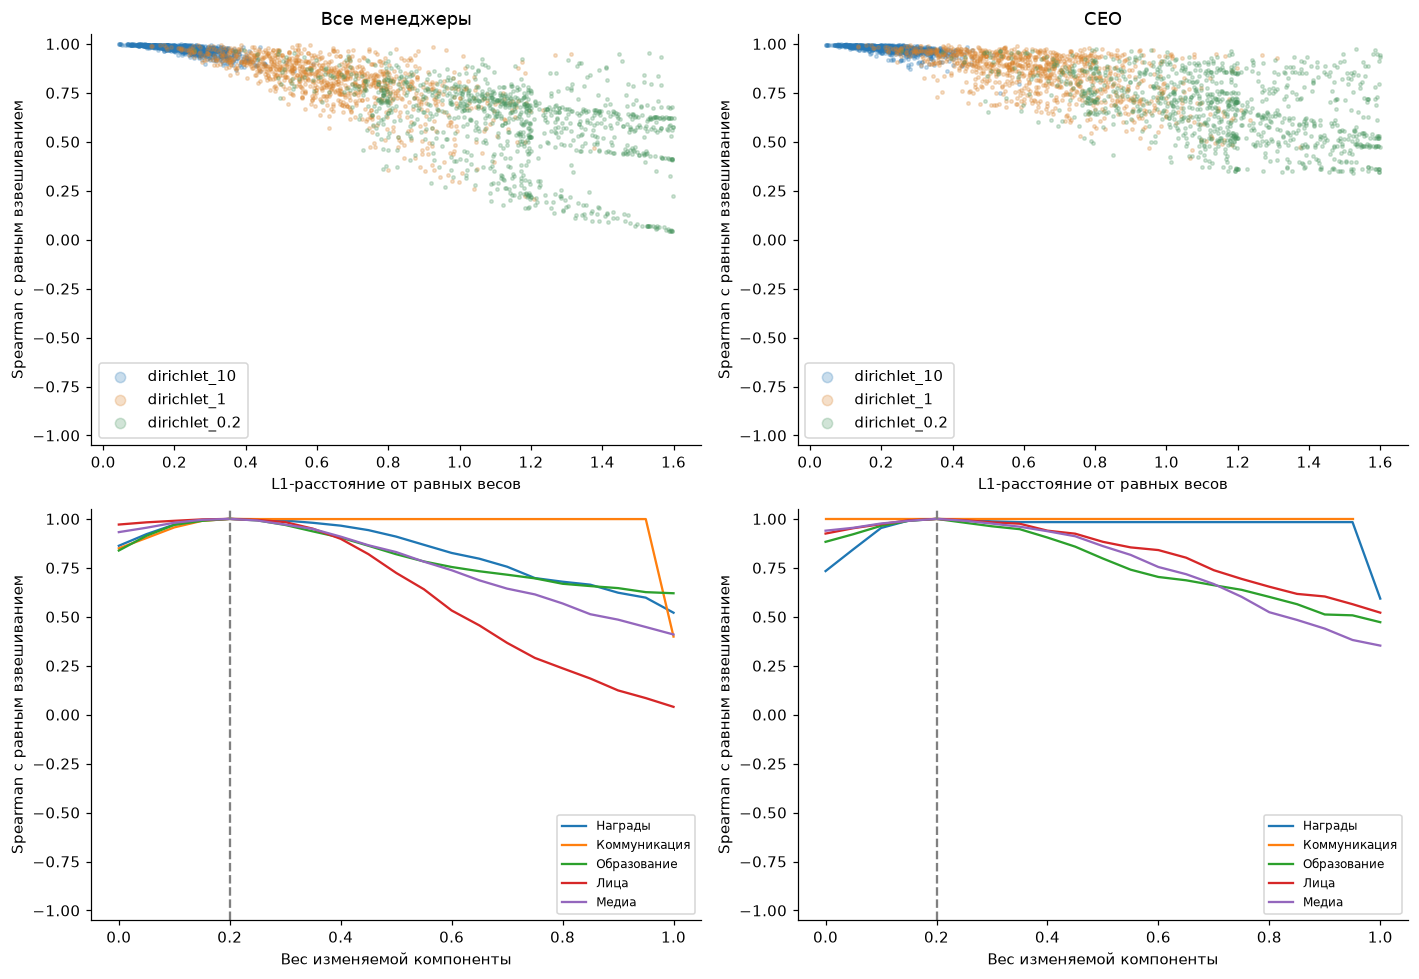

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
colors = ['#2878B5', '#D9822B', '#499660']
for col, (sample, metrics) in enumerate(sensitivity.items()):
    for color, family in zip(colors, ['dirichlet_10', 'dirichlet_1', 'dirichlet_0.2']):
        subset = metrics[metrics.family.eq(family)]
        axes[0, col].scatter(subset.l1_from_equal, subset.spearman, s=5, alpha=.25, label=family, color=color)
    axes[0, col].set(title=SAMPLE_LABELS[sample], xlabel='L1-расстояние от равных весов', ylabel='Spearman с равным взвешиванием', ylim=(-1.05, 1.05))
    axes[0, col].legend(markerscale=3)
    grid = metrics[metrics.family.eq('one_at_a_time')]
    for component, subset in grid.groupby('varied_component'):
        axes[1, col].plot(subset.target_weight, subset.spearman, label=LABELS[component])
    axes[1, col].axvline(.2, linestyle='--', color='gray')
    axes[1, col].set(xlabel='Вес изменяемой компоненты', ylabel='Spearman с равным взвешиванием', ylim=(-1.05, 1.05))
    axes[1, col].legend(fontsize=8)
finish_figure(fig, 'weight_robustness')

## Бутстрап CRITIC: веса и устойчивость рейтинга

Для каждой выборки выполняем `N_BOOTSTRAP` повторений. В каждом повторении из
полной матрицы **n компаний выбираем n строк с возвращением**. Размер n показан
ниже; это не число уникальных компаний в повторе. Все пять компонент компании
переносятся совместно, чтобы сохранить их зависимость. Веса CRITIC пересчитываются
по бутстрап-выборке, затем применяются к **исходным n компаниям**. Поэтому ранги
каждый раз сопоставимы, а повторяющиеся компании не дублируются в рейтинге.

Сохраняем 2.5-й и 97.5-й процентили весов, баллов и рангов; вероятности попадания в
топ-10; Spearman и Kendall относительно равных весов и точечного CRITIC.
Это условная неопределённость **внешних весов** при фиксированных компонентах:
ошибки исходных данных, отбор компаний с полными данными, искусственные границы
и внутренние веса образования не перебутстрапируются. Интервалы рангов могут
иметь дробные границы из-за ничьих и интерполяции квантилей.
Неудачные повторения не заменяются равными весами, причины сохраняются.

In [10]:
bootstrap, bootstrap_audit = {}, []
for number, (sample, x) in enumerate(matrices.items()):
    print(f'{SAMPLE_LABELS[sample]}: {N_BOOTSTRAP} повторений, по {len(x)} строк компаний с возвращением.')
    result = bootstrap_critic(x, repetitions=N_BOOTSTRAP, seed=SEED + 100 + number, top_k=TOP_K)
    bootstrap[sample] = result
    for name, table in result.items():
        save_table(table, f'{sample}_bootstrap_{name}')
    audit = result['audit']
    bootstrap_audit.append({'sample': sample, 'attempted': len(audit),
        'successful': int(audit.status.eq('ok').sum()), 'failed': int(audit.status.eq('failed').sum()),
        'rows_per_draw': len(x), 'unique_companies_min': audit.unique_companies.min(),
        'unique_companies_median': audit.unique_companies.median(),
        'unique_companies_max': audit.unique_companies.max()})
    display(result['weight_summary'].round(4))
bootstrap_audit = pd.DataFrame(bootstrap_audit).set_index('sample')
display(bootstrap_audit)
save_table(bootstrap_audit, 'bootstrap_audit')

Все менеджеры: 2000 повторений, по 64 строк компаний с возвращением.


,point,mean,std,p025,median,p975
component,,,,,,
media_score,0.1294,0.1340,0.0219,0.0992,0.1315,0.1822
awards_score,0.2240,0.2247,0.0435,0.1413,0.2234,0.3063
expertise_score,0.2053,0.2130,0.0331,0.1568,0.2105,0.2847
face_score,0.1421,0.1456,0.0197,0.1138,0.1435,0.1905
communication_score,0.2992,0.2827,0.0696,0.1458,0.2926,0.3896


CEO: 2000 повторений, по 28 строк компаний с возвращением.


,point,mean,std,p025,median,p975
component,,,,,,
media_score,0.1571,0.1603,0.0303,0.1087,0.1579,0.2252
awards_score,0.4090,0.3993,0.0772,0.2083,0.4074,0.5214
expertise_score,0.2828,0.2859,0.0473,0.2036,0.2824,0.3903
face_score,0.1511,0.1545,0.0286,0.1048,0.1520,0.2151
communication_score,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


,attempted,successful,failed,rows_per_draw,unique_companies_min,unique_companies_median,unique_companies_max
sample,,,,,,,
all_managers,2000,2000,0,64,31,41.0,50
ceo,2000,2000,0,28,13,18.0,25


Корреляции бутстрап-рейтингов: **Все менеджеры**

,count,mean,std,min,2.5%,50%,97.5%,max
spearman_vs_equal,2000.0,0.9849,0.0185,0.8215,0.9639,0.9877,0.9960,0.9980
kendall_tau_b_vs_equal,2000.0,0.9178,0.0261,0.7688,0.8631,0.9187,0.9593,0.9772
spearman_vs_point_critic,2000.0,0.9925,0.0202,0.8082,0.9730,0.9967,0.9996,1.0000
kendall_tau_b_vs_point_critic,2000.0,0.9572,0.0284,0.7738,0.8928,0.9633,0.9911,1.0000


Корреляции бутстрап-рейтингов: **CEO**

,count,mean,std,min,2.5%,50%,97.5%,max
spearman_vs_equal,2000.0,0.9649,0.0222,0.6574,0.9502,0.9666,0.9808,0.9929
kendall_tau_b_vs_equal,2000.0,0.8633,0.0334,0.5238,0.8095,0.8677,0.9153,0.9524
spearman_vs_point_critic,2000.0,0.9881,0.0304,0.5972,0.9386,0.9934,0.9995,1.0000
kendall_tau_b_vs_point_critic,2000.0,0.9523,0.0415,0.5238,0.8571,0.9577,0.9947,1.0000


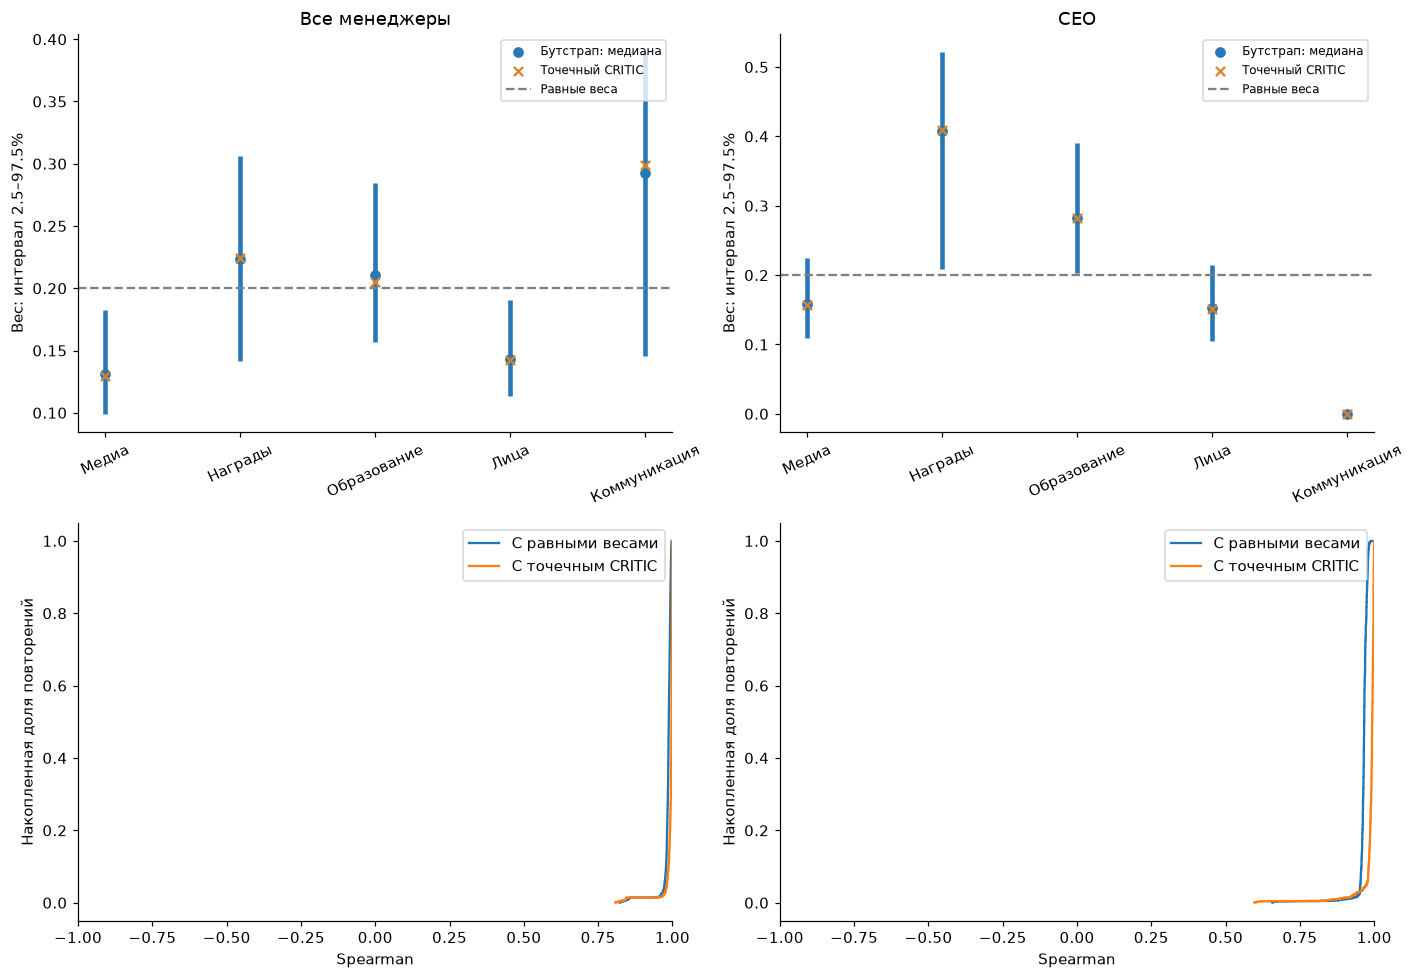

In [11]:
bootstrap_metric_summary = []
for sample, result in bootstrap.items():
    metrics = result['metrics']
    summary = metrics.describe(percentiles=[.025, .5, .975]).T
    save_table(summary, f'{sample}_bootstrap_metric_summary')
    display(Markdown('Корреляции бутстрап-рейтингов: **' + SAMPLE_LABELS[sample] + '**'))
    display(summary.loc[[c for c in metrics if c.startswith(('spearman_', 'kendall_'))]].round(4))
    for reference in ['equal', 'point_critic']:
        values = metrics[f'spearman_vs_{reference}'].dropna()
        bootstrap_metric_summary.append({'sample': sample, 'reference': reference,
            'spearman_p025': values.quantile(.025), 'spearman_median': values.median(),
            'spearman_p975': values.quantile(.975), 'share_below_09': values.lt(.9).mean(),
            'undefined': int(metrics[f'spearman_vs_{reference}'].isna().sum())})
bootstrap_metric_summary = pd.DataFrame(bootstrap_metric_summary)
save_table(bootstrap_metric_summary, 'bootstrap_rank_summary', index=False)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for col, (sample, result) in enumerate(bootstrap.items()):
    summary = result['weight_summary'].reindex(COMPONENTS)
    positions = np.arange(len(COMPONENTS))
    axes[0, col].vlines(positions, summary.p025, summary.p975, lw=3, color='#2878B5')
    axes[0, col].scatter(positions, summary['median'], label='Бутстрап: медиана', color='#2878B5')
    axes[0, col].scatter(positions, summary.point, marker='x', label='Точечный CRITIC', color='#D9822B', zorder=3)
    axes[0, col].axhline(.2, linestyle='--', color='gray', label='Равные веса')
    axes[0, col].set(xticks=positions, xticklabels=list(LABELS.values()), ylabel='Вес: интервал 2.5–97.5%', title=SAMPLE_LABELS[sample])
    axes[0, col].tick_params(axis='x', rotation=25)
    axes[0, col].legend(fontsize=8)
    for ref, label in [('equal', 'С равными весами'), ('point_critic', 'С точечным CRITIC')]:
        values = np.sort(result['metrics'][f'spearman_vs_{ref}'].dropna())
        axes[1, col].step(values, np.arange(1, len(values) + 1) / len(values), where='post', label=label)
    axes[1, col].set(xlabel='Spearman', ylabel='Накопленная доля повторений', xlim=(-1, 1))
    axes[1, col].legend()
finish_figure(fig, 'critic_bootstrap')

Компании с лучшими точечными рангами: **Все менеджеры**

,equal_score,critic_score,equal_rank,critic_rank,score_p025,score_p975,rank_p025,rank_median,rank_p975,top_k_probability
ticker,,,,,,,,,,
APTK,68.098,73.105,1.0,1.0,67.324,76.394,1.0,1.0,1.000,1.000
RENI,58.915,63.222,3.0,2.0,55.074,68.076,2.0,2.0,5.000,1.000
FIVE,59.403,63.039,2.0,3.0,54.097,68.913,2.0,3.0,3.000,1.000
GMKN,56.237,60.865,6.0,4.0,51.995,66.434,4.0,4.0,6.000,1.000
MTSS,57.811,60.771,4.0,5.0,51.429,67.053,4.0,5.0,6.000,1.000
AGRO,57.062,59.387,5.0,6.0,48.645,66.975,3.0,6.0,8.000,0.999
SGZH,54.347,58.333,8.0,7.0,49.003,64.199,6.0,7.0,20.025,0.745
ASTR,54.261,58.228,9.0,8.0,48.213,64.799,7.0,8.0,10.000,0.996
CIAN,54.486,57.770,7.0,9.0,47.252,64.939,7.0,9.0,11.000,0.858


Компании с лучшими точечными рангами: **CEO**

,equal_score,critic_score,equal_rank,critic_rank,score_p025,score_p975,rank_p025,rank_median,rank_p975,top_k_probability
ticker,,,,,,,,,,
HEAD,63.567,53.971,2.0,1.0,52.170,55.320,1.000,1.0,2.0,0.996
FIVE,64.177,53.350,1.0,2.0,52.695,54.170,1.000,2.0,2.0,0.996
RENI,58.297,46.961,4.0,3.0,44.523,48.919,3.000,3.0,10.0,0.976
DATA,58.733,42.281,3.0,4.0,38.672,48.940,3.000,4.0,4.0,1.000
DELI,54.419,36.788,12.0,5.0,34.229,41.509,5.000,5.0,16.0,0.847
ETLN,56.687,36.477,7.0,6.0,29.552,48.980,4.000,6.0,8.0,1.000
NKNC,58.292,36.266,5.0,7.0,29.459,48.564,4.000,6.0,9.0,1.000
MRKV,57.159,36.026,6.0,8.0,29.189,48.299,5.975,8.0,9.0,1.000
AGRO,56.530,35.708,8.0,9.0,28.892,47.708,6.000,9.0,9.0,1.000


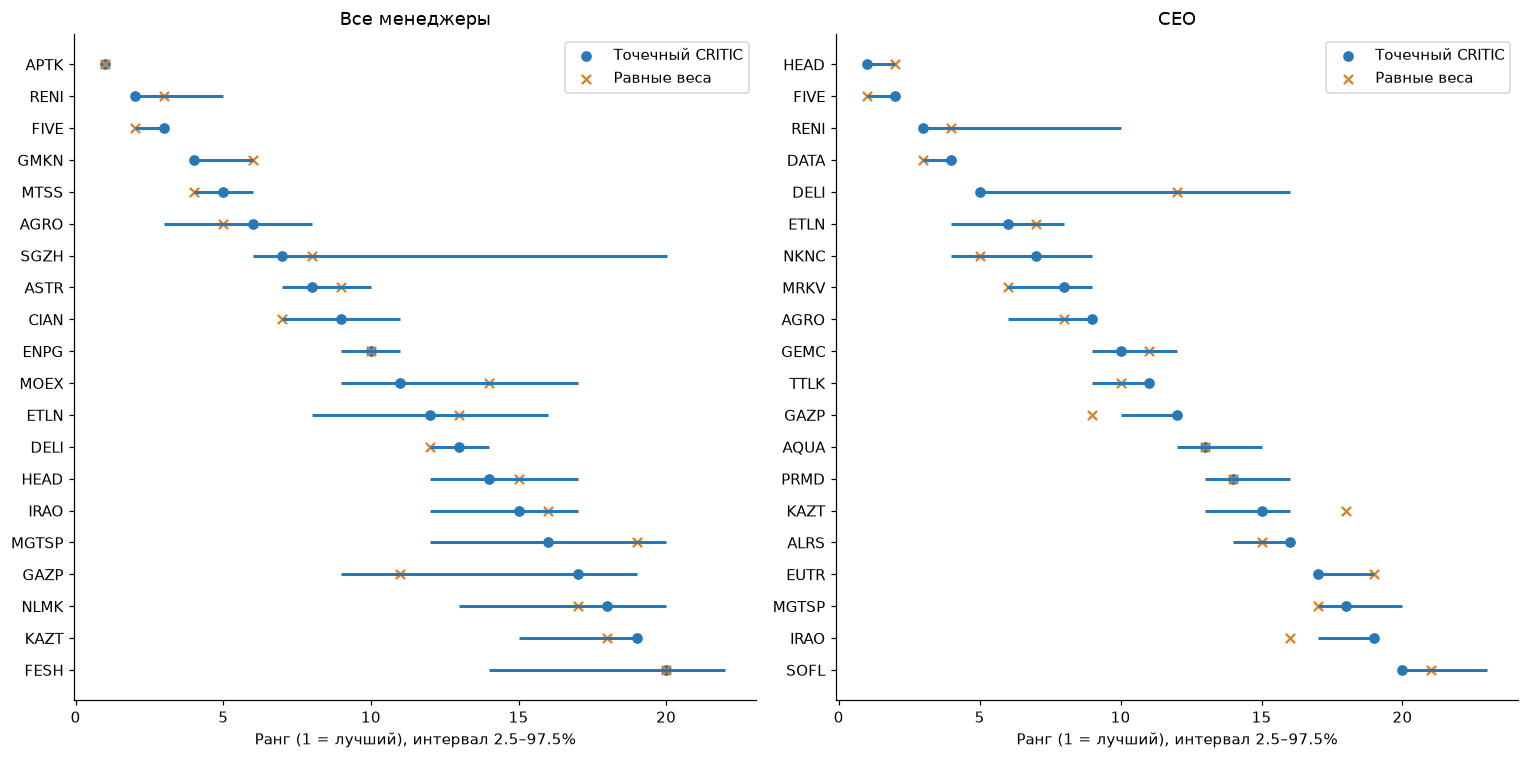

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, (sample, result) in zip(axes, bootstrap.items()):
    table = result['company_summary'].sort_values('critic_rank')
    display(Markdown('Компании с лучшими точечными рангами: **' + SAMPLE_LABELS[sample] + '**'))
    display(table.head(15).round(3))
    selected = table.head(20).iloc[::-1]
    pos = np.arange(len(selected))
    ax.hlines(pos, selected.rank_p025, selected.rank_p975, lw=2, color='#2878B5')
    ax.scatter(selected.critic_rank, pos, label='Точечный CRITIC', color='#2878B5')
    ax.scatter(selected.equal_rank, pos, marker='x', label='Равные веса', color='#D9822B')
    ax.set(yticks=pos, yticklabels=selected.index, xlabel='Ранг (1 = лучший), интервал 2.5–97.5%', title=SAMPLE_LABELS[sample])
    ax.legend()
finish_figure(fig, 'bootstrap_rank_intervals')

## Чувствительность к составу компонент и охвату

Для каждой исключённой компоненты рассматриваем два изменения отдельно:

1. На исходной полной выборке обнуляем её вес, остальные делаем равными —
   это чистое изменение весов без изменения компаний.
2. Включаем все компании с четырьмя оставшимися компонентами и заново оцениваем
   четырёхкомпонентный CRITIC. Его сравниваем с четырёхкомпонентными равными весами
   на этом же расширенном составе. Для сравнения с исходным пятикритериальным
   рейтингом сначала ограничиваемся исходными полными компаниями и заново ранжируем их.

Четырёхкомпонентные индексы — отдельные спецификации, а не заполнение пропусков
основного индекса. Их численные баллы и места в разных по размеру рейтингах
нельзя считать взаимозаменяемыми.

In [13]:
component_sensitivity = []
for sample, df in data.items():
    original = matrices[sample]
    for excluded in COMPONENTS:
        remaining = [c for c in COMPONENTS if c != excluded]
        expanded = df[remaining].dropna() / 100
        w, details = critic_weights(expanded)
        equal_scores, critic_scores = expanded.mean(axis=1), expanded.dot(w)
        fixed_metrics = ranking_metrics(original.mean(axis=1), original[remaining].mean(axis=1), top_k=TOP_K)
        expanded_metrics = ranking_metrics(equal_scores, critic_scores, top_k=TOP_K)
        common_metrics = ranking_metrics(original.mean(axis=1), critic_scores.reindex(original.index), top_k=TOP_K)
        component_sensitivity.append({'sample': sample, 'excluded': excluded,
            'original_n': len(original), 'expanded_n': len(expanded),
            'added_companies': len(expanded) - len(original),
            'fixed_cohort_spearman_vs_equal5': fixed_metrics['spearman'],
            'expanded_critic_vs_equal4_spearman': expanded_metrics['spearman'],
            'original_cohort_critic4_vs_equal5_spearman': common_metrics['spearman']})
        save_table(details, f'{sample}_without_{excluded}_critic')
        save_table(pd.DataFrame({'equal4': 100 * equal_scores, 'critic4': 100 * critic_scores}),
                   f'{sample}_without_{excluded}_indices')
component_sensitivity = pd.DataFrame(component_sensitivity)
display(component_sensitivity.round(4))
save_table(component_sensitivity, 'component_set_sensitivity', index=False)

,sample,excluded,original_n,expanded_n,added_companies,fixed_cohort_spearman_vs_equal5,expanded_critic_vs_equal4_spearman,original_cohort_critic4_vs_equal5_spearman
0,all_managers,media_score,64,64,0,0.9324,0.9923,0.9282
1,all_managers,awards_score,64,64,0,0.8627,0.9793,0.8751
2,all_managers,expertise_score,64,64,0,0.8385,0.9776,0.8321
3,all_managers,face_score,64,83,19,0.9712,0.9867,0.9612
4,all_managers,communication_score,64,79,15,0.8497,0.9920,0.8354
5,ceo,media_score,28,34,6,0.9398,0.9829,0.9163
6,ceo,awards_score,28,28,0,0.7334,0.9704,0.6880
7,ceo,expertise_score,28,29,1,0.8829,0.9961,0.8763
8,ceo,face_score,28,59,31,0.9250,0.9766,0.9070
9,ceo,communication_score,28,35,7,1.0000,0.9706,0.9644


## Все менеджеры и CEO на общем составе компаний

Сопоставляем доступные значения компонент попарно. Для итоговых рейтингов используем
пересечение двух полных выборок и заново ранжируем только эти компании. CRITIC-веса
остаются оценёнными на своих основных выборках; различия CRITIC-рейтингов включают
и различия компонент, и различия весов. Даже сравнение с равными внешними весами
сохраняет различия внутренних образовательных весов, рассчитанных ранее отдельно.

In [14]:
cross_sample = []
for col in COMPONENTS:
    pair = pd.concat([data['all_managers'][col], data['ceo'][col]], axis=1, keys=['all', 'ceo']).dropna()
    cross_sample.append({'measure': col, 'companies': len(pair), **ranking_metrics(pair['all'], pair.ceo, top_k=TOP_K)})
common = matrices['all_managers'].index.intersection(matrices['ceo'].index)
for method in ['equal', 'critic']:
    a = index_tables['all_managers'].loc[common, f'index_{method}']
    b = index_tables['ceo'].loc[common, f'index_{method}']
    cross_sample.append({'measure': f'index_{method}', 'companies': len(common), **ranking_metrics(a, b, top_k=TOP_K)})
cross_sample = pd.DataFrame(cross_sample)
display(cross_sample.round(4))
save_table(cross_sample, 'all_vs_ceo', index=False)

,measure,companies,spearman,kendall_tau_b,mean_abs_rank_shift,max_abs_rank_shift,top_k_jaccard
0,media_score,78,0.5413,0.4090,16.0128,70.0,0.1765
1,awards_score,91,0.5882,0.4887,18.4066,48.5,0.5000
2,expertise_score,105,0.4617,0.3315,24.3238,92.0,0.4286
3,face_score,43,0.6146,0.4499,8.0000,26.0,0.2500
4,communication_score,83,1.0000,1.0000,0.0000,0.0,1.0000
5,index_equal,28,0.5610,0.4127,5.8571,17.0,0.4286
6,index_critic,28,0.6054,0.4233,5.3571,16.0,0.4286


## Выводы и воспроизводимость

Ниже выводы подставляются из фактических расчётов, чтобы при обновлении CSV они
не оставались устаревшими. Основные ограничения: отбор по полноте данных,
неопределённость исходных измерений, зависимость от фиксированных границ шкал,
и отсутствие внешнего критерия качества репутации. Высокая ранговая корреляция
показывает устойчивость к рассмотренному изменению весов, но сама по себе
не подтверждает содержательную валидность индекса.

In [15]:
lines = []
for sample in data:
    n = len(matrices[sample])
    rho = point_metrics.loc[sample, 'spearman']
    boot = bootstrap[sample]
    lower, upper = boot['metrics'].spearman_vs_point_critic.quantile([.025, .975])
    random_summary = summary_sensitivity[(summary_sensitivity['sample'] == sample) & (summary_sensitivity.family == 'dirichlet_1')].iloc[0]
    leading = point_weights[sample].critic.idxmax()
    lines.append(f"**{SAMPLE_LABELS[sample]}:** полный рейтинг охватывает {n} из {len(data[sample])} компаний. "
                 f"Spearman CRITIC с равными весами = {rho:.3f}. Наибольший вес CRITIC: {LABELS[leading]} "
                 f"({point_weights[sample].loc[leading, 'critic']:.1%}). При равномерном переборе симплекса "
                 f"(Dirichlet 1) медиана Spearman = {random_summary.spearman_median:.3f}, "
                 f"5-й процентиль = {random_summary.spearman_p05:.3f}. "
                 f"Бутстрап: {N_BOOTSTRAP} повторений по {n} строк с возвращением; "
                 f"интервал 2.5–97.5% Spearman с точечным CRITIC = [{lower:.3f}; {upper:.3f}].")
conclusion = '\n\n'.join(lines)
display(Markdown(conclusion))
(OUT / 'findings.md').write_text(conclusion + '\n', encoding='utf-8')
manifest = {
    'inputs': {sample: {'path': str(path.relative_to(ROOT)), 'sha256': hashlib.sha256(path.read_bytes()).hexdigest()}
               for sample, path in INPUTS.items()},
    'seed': SEED, 'random_draws_per_alpha': N_RANDOM, 'dirichlet_alphas': [10, 1, .2],
    'bootstrap_repetitions': N_BOOTSTRAP, 'bootstrap_seeds': {'all_managers': SEED + 100, 'ceo': SEED + 101},
    'bootstrap_sample_sizes': {sample: len(x) for sample, x in matrices.items()},
    'components': COMPONENTS, 'top_k': TOP_K, 'missing_policy': 'complete case for index; pairwise for EDA',
    'normalization': 'existing fixed 0–100 scales / 100; no sample min-max',
    'bootstrap_scope': 'company rows; outer weights only; scores and inner education weights fixed',
    'versions': {'python': platform.python_version(), 'numpy': np.__version__, 'pandas': pd.__version__,
                 'scipy': scipy.__version__, 'matplotlib': matplotlib.__version__},
}
(OUT / 'manifest.json').write_text(json.dumps(manifest, ensure_ascii=False, indent=2) + '\n', encoding='utf-8')
print('Таблицы:', OUT)
print('PDF:', FIGS / 'index_eda_*.pdf')

**Все менеджеры:** полный рейтинг охватывает 64 из 110 компаний. Spearman CRITIC с равными весами = 0.989. Наибольший вес CRITIC: Коммуникация (29.9%). При равномерном переборе симплекса (Dirichlet 1) медиана Spearman = 0.839, 5-й процентиль = 0.556. Бутстрап: 2000 повторений по 64 строк с возвращением; интервал 2.5–97.5% Spearman с точечным CRITIC = [0.973; 1.000].

**CEO:** полный рейтинг охватывает 28 из 110 компаний. Spearman CRITIC с равными весами = 0.963. Наибольший вес CRITIC: Награды (40.9%). При равномерном переборе симплекса (Dirichlet 1) медиана Spearman = 0.885, 5-й процентиль = 0.631. Бутстрап: 2000 повторений по 28 строк с возвращением; интервал 2.5–97.5% Spearman с точечным CRITIC = [0.939; 0.999].

Таблицы: /Users/mac/Reputation project/results/index_eda
PDF: /Users/mac/Reputation project/figs/index_eda_*.pdf
